In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)
from pathlib import Path

from data_generation.models.general_ode_solver import GeneralODENumericalSolver
from data_generation.models.saddle_system import MultiSaddleSystem

from data_generation.simulations.grid import logistic_transformation, Grid

In [4]:
def improved_multi_saddle_visualization(k=2, saddle_points=None, angles=None, 
                                      lambda1=1.0, lambda2=-1.0,
                                      grid_size=20, 
                                      domain_size=2.0):
    """
    Create an improved visualization of the MultiSaddleSystem with:
    - A clear halfspace division map showing all combinations
    - A streamlined dynamics plot with better visibility
    - Unstable manifolds shown with soft lines
    """
    
    # Create the system
    system = MultiSaddleSystem(k=k, saddle_points=saddle_points, 
                              angles=angles, lambda1=lambda1, lambda2=lambda2)
    
    # Create the solver
    solver = GeneralODENumericalSolver(system)
    
    # Set up plotting grid
    x1 = np.linspace(-domain_size, domain_size, grid_size)
    x2 = np.linspace(-domain_size, domain_size, grid_size)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Create a 2x1 figure: one for halfspace divisions, one for dynamics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ====== Plot 1: Halfspace Division Map ======
    ax1.set_title("Halfspace Divisions", fontsize=14)
    
    # Compute halfspace values across the grid
    halfspace_grid = np.zeros((grid_size, grid_size, k), dtype=int)
    for i in range(grid_size):
        for j in range(grid_size):
            point = np.array([X1[i, j], X2[i, j]])
            halfspace_values = system.halfspace_values(point)
            # Convert to integers (0 or 1)
            halfspace_grid[i, j] = (halfspace_values > 0.5).astype(int)
    
    # Create a color map that clearly distinguishes all 2^k combinations
    num_combinations = 2**k
    distinct_colors = plt.cm.tab10(np.linspace(0, 1, num_combinations))
    custom_cmap = ListedColormap(distinct_colors)
    
    # Compute the region index for each point (binary to decimal conversion)
    region_indices = np.zeros((grid_size, grid_size), dtype=int)
    for i in range(k):
        region_indices += halfspace_grid[:, :, i] * (2**i)
    
    # Plot region map
    halfspace_map = ax1.imshow(region_indices, 
                              extent=[-domain_size, domain_size, -domain_size, domain_size],
                              origin='lower', aspect='auto', cmap=custom_cmap,
                              vmin=0, vmax=num_combinations-1)
    
    # Create a proper legend showing each combination
    legend_patches = []
    for i in range(num_combinations):
        # Convert index to binary representation
        binary = format(i, f'0{k}b')
        # Create label showing which halfspaces are positive (1) or negative (0)
        label = f"Halfspaces: "
        for j in range(k):
            label += f"{j}={'positive' if binary[j]=='1' else 'negative'}, "
        label = label[:-2]  # Remove trailing comma
        legend_patches.append(mpatches.Patch(color=distinct_colors[i], label=label))
    
    # Add a proper legend
    ax1.legend(handles=legend_patches, loc='upper center', 
              bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
    
    # Plot saddle points and stable manifolds
    for i in range(k):
        saddle = system.saddle_points[i]
        direction = system.directions[i]
        
        # Plot saddle point
        ax1.plot(saddle[0], saddle[1], 'ko', markersize=8)
        
        # Plot stable manifold line
        t = np.linspace(-domain_size*1.5, domain_size*1.5, 100)
        line_x1 = saddle[0] + t * direction[0]
        line_x2 = saddle[1] + t * direction[1]
        ax1.plot(line_x1, line_x2, 'k--', linewidth=1.5)
        
        # Calculate unstable manifold direction (perpendicular to stable)
        unstable_dir = np.array([-direction[1], direction[0]])
        
        # Plot unstable manifold line (with softer style)
        unstable_line_x1 = saddle[0] + t * unstable_dir[0]
        unstable_line_x2 = saddle[1] + t * unstable_dir[1]
        ax1.plot(unstable_line_x1, unstable_line_x2, 'k:', linewidth=1.0, alpha=0.6)
    
    ax1.set_xlim([-domain_size, domain_size])
    ax1.set_ylim([-domain_size, domain_size])
    ax1.set_xlabel("x1", fontsize=12)
    ax1.set_ylabel("x2", fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # ====== Plot 2: Improved Combined Dynamics Streamplot ======
    ax2.set_title("Combined Dynamics", fontsize=14)
    
    # Define color tuples with transparency (RGBA) for each dynamics
    # Format: (R, G, B, alpha)
    colors_rgba = [
        (1.0, 0.0, 0.0, 0.6),  # Red with transparency
        (0.0, 0.0, 1.0, 0.6),  # Blue with transparency
        (0.0, 0.8, 0.0, 0.6),  # Green with transparency
        (1.0, 0.5, 0.0, 0.6),  # Orange with transparency
        (0.8, 0.0, 0.8, 0.6),  # Purple with transparency
        (0.6, 0.3, 0.0, 0.6),  # Brown with transparency
    ]
    
    # Draw streamplots with different colors for each saddle
    for i in range(k):
        # Compute vector field for this saddle
        control_array = np.full((X1.size, 1), i)  # Select this saddle for all points
        points = np.column_stack((X1.flatten(), X2.flatten()))
        
        # Get derivatives using the solver
        derivatives = solver.get_derivative(points, control_array)
        
        # Reshape derivatives back to grid
        U = derivatives[:, 0].reshape(X1.shape)
        V = derivatives[:, 1].reshape(X2.shape)
        
        # Use RGBA color with built-in transparency
        color = colors_rgba[i % len(colors_rgba)]
        
        # Plot streamlines with reduced density
        strm = ax2.streamplot(X1, X2, U, V, color=color, 
                            linewidth=0.8, density=0.7, arrowsize=1.2)
        
        # Plot saddle point - larger as requested
        saddle = system.saddle_points[i]
        ax2.plot(saddle[0], saddle[1], 'o', color=color[:3], markersize=10)
        
        # Plot stable manifold with increased visibility
        direction = system.directions[i]
        t = np.linspace(-domain_size*1.5, domain_size*1.5, 100)
        line_x1 = saddle[0] + t * direction[0]
        line_x2 = saddle[1] + t * direction[1]
        ax2.plot(line_x1, line_x2, '-', color=color[:3], linewidth=2.5)
        
        # Calculate unstable manifold direction (perpendicular to stable)
        unstable_dir = np.array([-direction[1], direction[0]])
        
        # Plot unstable manifold with a softer line style
        unstable_line_x1 = saddle[0] + t * unstable_dir[0]
        unstable_line_x2 = saddle[1] + t * unstable_dir[1]
        ax2.plot(unstable_line_x1, unstable_line_x2, ':', color=color[:3], 
               linewidth=1.5, alpha=0.7)  # Dotted line with transparency
    
    # No legend as requested
    
    ax2.set_xlim([-domain_size, domain_size])
    ax2.set_ylim([-domain_size, domain_size])
    ax2.set_xlabel("x1", fontsize=12)
    ax2.set_ylabel("x2", fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Make room for the legend
    plt.show()
    
    return system, solver, fig

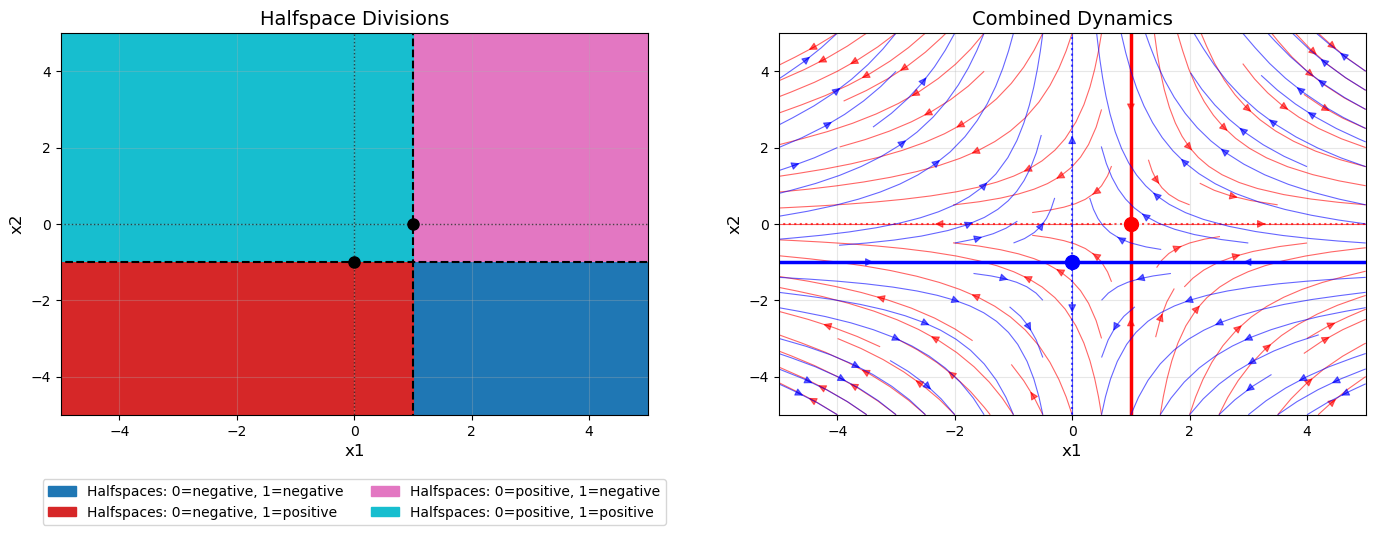

In [5]:
# Example with custom configuration:
saddle_points = [np.array([1.0, 0.0]), np.array([0.0, -1.0])]
angles = [90, 0]  # in degrees
system, solver, fig = improved_multi_saddle_visualization(
    k=2, 
    saddle_points=saddle_points, 
    angles=angles, 
    lambda1=1.0, 
    lambda2=-1.0,
    domain_size=5.0
)

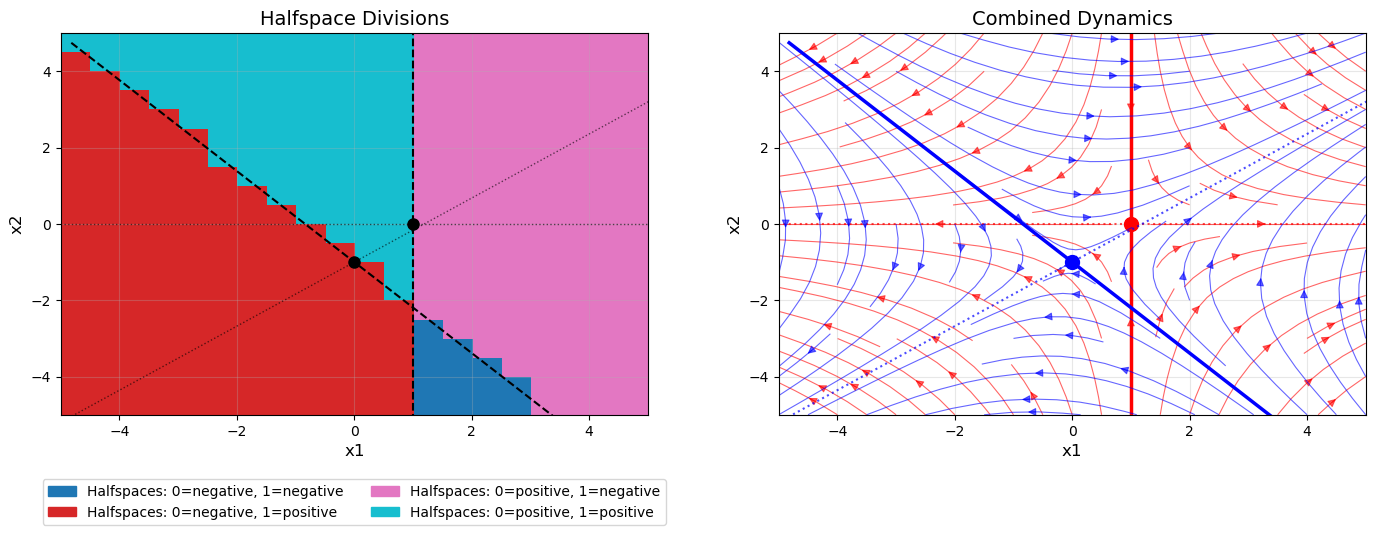

In [6]:
# Example with custom configuration:
saddle_points = [np.array([1.0, 0.0]), np.array([0, -1.0])]
angles = [90, 310]  # in degrees
system, solver, fig = improved_multi_saddle_visualization(
    k=2, 
    saddle_points=saddle_points, 
    angles=angles, 
    lambda1=1.0, 
    lambda2=-1.0,
    domain_size=5.0
)

In [7]:
# Create transformations for both dimensions
transformations = [
    logistic_transformation({'k': 1, 'x_0': 0}),  # For x1 dimension
    logistic_transformation({'k': 1, 'x_0': 0})   # For x2 dimension
]

# Create grid with these transformations
grid = Grid(
    bounds=[(-np.inf, np.inf), (-np.inf, np.inf)],
    resolution=[20, 20],
    grid_transformations=transformations
)

In [38]:
from data_generation.simulations.simulator import Simulator
import matplotlib.pyplot as plt

# Test the MultiSaddleSystem
def test_multi_saddle_sampling():
    # 1. Create logistic transformations focused on the range (-5, 5)
    # Using k=0.5 to better spread the transformation in our range of interest
    transformations = [
        logistic_transformation({'k': 0.5, 'x_0': 0}),  # For x1 dimension
        logistic_transformation({'k': 0.5, 'x_0': 0})   # For x2 dimension
    ]

    # Create grid with these transformations
    grid = Grid(
        bounds=[(-np.inf, np.inf), (-np.inf, np.inf)],  # Full range handled by logistic transformation
        resolution=[5, 5],  # 5x5 grid cells
        grid_transformations=transformations
    )

    # Create saddle system with 2 saddles in the (-5, 5) range
    saddle_points = [
        np.array([1.0, 0.0]),    # First saddle 
        np.array([0.0, -1.0])   # Second saddle 
    ]
    angles = [90, 310]  # in degrees
    system = MultiSaddleSystem(
        k=2, 
        saddle_points=saddle_points, 
        angles=angles
    )

    # Create numerical solver and simulator
    solver = GeneralODENumericalSolver(system)
    simulator = Simulator(grid, system, solver)

    # 2. Run simulation with delta_t=1, 3 steps
    # Use the first saddle dynamics (control=0)
    control = [0]
    
    results = simulator.simulate(
        control=control,
        delta_t=1.0,
        avg_samples_per_cell=3,  # 3 samples per grid cell
        num_steps=2,
        save_result=True
    )

    print(f"Generated {len(results)} trajectory segments")
    print(f"Number of unique starting points: {len(results['trajectory_id'].unique())}")
    
    # Print a few rows to inspect the data
    print("\nSample of generated data:")
    print(results.head())
    
    # Visualize some trajectories
    visualize_trajectories(results, saddle_points)
    
    return grid, system, solver, simulator, results

def visualize_trajectories(results, saddle_points, max_trajectories=1000):
    """Visualize a subset of trajectories"""
    # Get unique trajectory IDs
    unique_trajectories = results['trajectory_id'].unique()
    n_trajectories = min(max_trajectories, len(unique_trajectories))
    
    plt.figure(figsize=(10, 8))
    
    # Plot trajectories
    for i in range(n_trajectories):
        traj_id = unique_trajectories[i]
        traj_data = results[results['trajectory_id'] == traj_id]
        
        # Create full trajectory path
        x_coords = []
        y_coords = []
        
        # Add starting point
        x_coords.append(traj_data.iloc[0]['x0'])  # First state dimension
        y_coords.append(traj_data.iloc[0]['x1'])  # Second state dimension
        
        # Add ending points for each step
        for j in range(len(traj_data)):
            x_coords.append(traj_data.iloc[j]['y0'])  # Result after step
            y_coords.append(traj_data.iloc[j]['y1'])
        
        plt.plot(x_coords, y_coords, 'o-', alpha=0.7)
    
    # Add saddle points
    for saddle in saddle_points:
        plt.plot(saddle[0], saddle[1], 'ko', markersize=10)
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Sample trajectories (control=0)')
    plt.grid(True)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.show()

Simulation complete (uniform sampling):
- 75 samples × 2 timesteps = 150 total rows
- State dimensions: 2
- Control dimensions: 1
Saved results and config.
Generated 150 trajectory segments
Number of unique starting points: 75

Sample of generated data:
            run_id trajectory_id   t0   t1         x0        x1  c0  \
0  20250507_125029         0-0_0  0.0  1.0  -4.310503 -6.665753   0   
1  20250507_125029         0-0_0  1.0  2.0 -13.436147 -2.451014   0   
2  20250507_125029         0-0_1  0.0  1.0  -6.449422 -3.312351   0   
3  20250507_125029         0-0_1  1.0  2.0 -19.250613 -1.217960   0   
4  20250507_125029         0-0_2  0.0  1.0  -8.121787 -3.112818   0   

          y0        y1  
0 -13.436147 -2.451014  
1 -38.240565 -0.902908  
2 -19.250613 -1.217960  
3 -54.045539 -0.448674  
4 -23.796796 -1.144591  


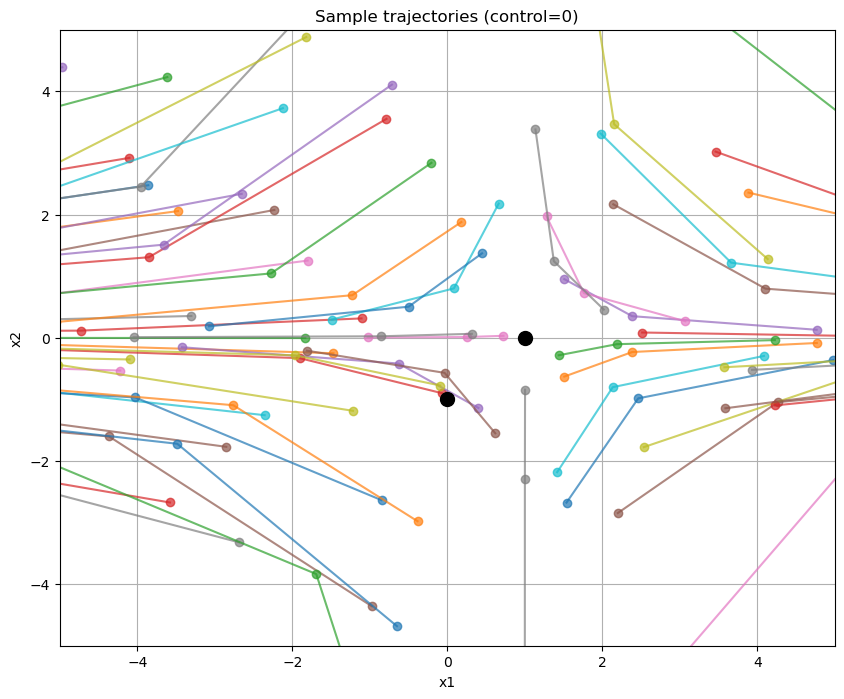

In [39]:
grid, system, solver, simulator, results = test_multi_saddle_sampling()

In [35]:
grid.grid_lines

[array([        inf, -5.88887796, -4.39444915, -3.46920211, -2.77258872,
        -2.19722458, -1.69459572, -1.23807842, -0.81093022, -0.40134139,
         0.        ,  0.40134139,  0.81093022,  1.23807842,  1.69459572,
         2.19722458,  2.77258872,  3.46920211,  4.39444915,  5.88887796,
                inf]),
 array([        inf, -5.88887796, -4.39444915, -3.46920211, -2.77258872,
        -2.19722458, -1.69459572, -1.23807842, -0.81093022, -0.40134139,
         0.        ,  0.40134139,  0.81093022,  1.23807842,  1.69459572,
         2.19722458,  2.77258872,  3.46920211,  4.39444915,  5.88887796,
                inf])]